# Trabalho de Integência Artificial

#### Alunos:

Pedro Henrique de Souza Lopes - 2024004528

Silvan José da Silva Júnior -

Bianca dos Reis Moraes -

O Objetivo desse trabalho é fazer uma analise do conjunto de dados "Breast Cancer Wisconsin (Diagnostic) Data Set" Disponivel em:

https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

A analise será feita por meio de metodos de aprendizado de maquina, tanto supervisonados quando não supervisonados, utilizando de tecnicas de agrupamento e tecnicas de agrupamento, as tecnicas abordadas serão, Modelo da Floresta Aleatoria, MLP e K-Médias, as funções que serão usadas para aplicação dessas tecnicas tem sua documentação disponivel em https://scikit-learn.org/stable/

As avaliações das Técnicas de classificação estarão disponiveis em https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report junto da matriz de classificação

As avaliações das Ténicas de Agrupamento iremos buscar uma medida de avaliação dos grupos obtidos

In [69]:
import pandas as pd
import sklearn

df = pd.read_csv("data.csv")
df.head()
df0=df

df.drop(["texture_worst","radius_worst"],axis=1)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,fractal_dimension_se,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,0.006193,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,0.003532,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,0.004571,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,0.009208,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,0.005115,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,0.004239,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,0.002498,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,0.003892,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,0.006185,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


### Metodo da Floresta Aleatoria

O metodo da floresta aleatoria opera criando arvores de decisão que filtram os dados, todavia uma só arvore seria imprecisa, logo o metodo cria varias dela e a resposta de cada uma é votada e a mais votada, e portanto a mais "correta" é a que o metodo devolve como resultado, essas arvores iteram sobre carateristicas aleatorias dos dados, gerando assim a floresta aleatoria de arvores de decisão

#### Teste 1: 100 arvores, 20% de teste



Separando os dados do df em dados de entrada e saida e separando os testes de treino do modelo

In [59]:
#separando dados de entrada
e1=df.drop(['diagnosis'], axis=1)

#separando vetor de saida
s1=df["diagnosis"]

#transformando valores não numericos em numericos
e1=pd.get_dummies(e1, drop_first=True)

#gerando dados de treino e de teste do modelo
e1train, e1test, s1train, s1test = sklearn.model_selection.train_test_split(
    e1,
    s1,
    test_size=0.2,#20% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [ ]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta1 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta1.fit(e1train,s1train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [ ]:
# faz o teste de previsão com o modelo treinado
prev1 = floresta1.predict(e1test)
print(sklearn.metrics.classification_report(s1test, prev1))

              precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 96% e a taxa de acerto quando a resposta era B foi de 97%, já quando a precisão quando a resposta foi M foi de 95% e a taxa de acerto quando a resposta era de fato M foi de 94%

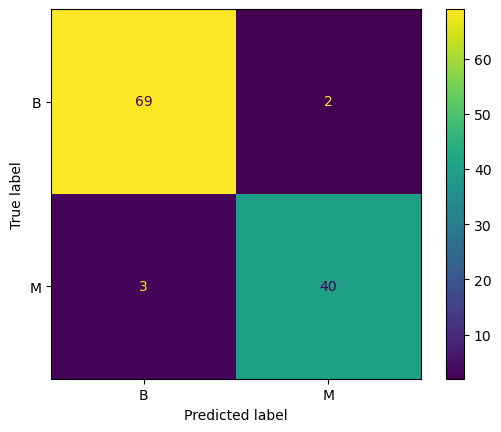

In [66]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s1test,
    prev1,
    display_labels=["B", "M"]
)

Com base na matriz, pode se interpretar que, de um total de casos B de 71, o modelo acertou 69 e um tital de casos M de 43 ele acertou 40.

In [ ]:
print(f"{sklearn.metrics.accuracy_score(s1test, prev1):.6f}")

0.956140


O valor acima é a precisão geral do modelo, que vai ser usado para a comparação com o data set sem a modificação, uma vez que a tecnica da floresta aleatoria é muito robusto e as alterações feitas no dataset não afetam muito o seu resultado

#### Teste 2: 200, 20% teste

Separando os dados do df em dados de entrada e saida e separando os testes de treino do modelo

In [70]:
#separando dados de entrada
e2=df0.drop(['diagnosis'], axis=1)

#separando vetor de saida
s2=df0["diagnosis"]

#transformando valores não numericos em numericos
e1=pd.get_dummies(e2, drop_first=True)

#gerando dados de treino e de teste do modelo
e2train, e2test, s2train, s2test = sklearn.model_selection.train_test_split(
    e2,
    s2,
    test_size=0.2,#20% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [71]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta2 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta2.fit(e1train,s1train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [72]:
# faz o teste de previsão com o modelo treinado
prev2 = floresta2.predict(e1test)
print(sklearn.metrics.classification_report(s2test, prev2))

              precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 96% e a taxa de acerto quando a resposta era B foi de 97%, já quando a precisão quando a resposta foi M foi de 95% e a taxa de acerto quando a resposta era de fato M foi de 94%

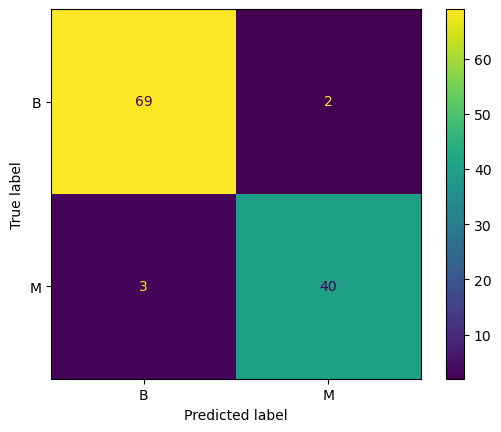

In [73]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s1test,
    prev1,
    display_labels=["B", "M"]
)

Com base na matriz, pode se interpretar que, de um total de casos B de 71, o modelo acertou 69 e um tital de casos M de 43 ele acertou 40.

In [74]:
print(f"{sklearn.metrics.accuracy_score(s1test, prev1):.6f}")

0.956140


O valor acima é a precisão geral do modelo, que vai ser usado para a comparação com o data set sem a modificação, uma vez que a tecnica da floresta aleatoria é muito robusto e as alterações feitas no dataset não afetam muito o seu resultado